# Demo — Breathing detection over WiFi (CSI)

A **still** person who breathes imprints a slow oscillation (~0.2–0.4 Hz) on the
CSI amplitude. Here we show it end to end on **synthetic data with known ground
truth**: generate → clean → estimate → visualize.

> Replacing `generate_breathing(...)` with a real ESP32 capture on capture day
> changes nothing else in the notebook: the data source is the only thing that varies.

In [1]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt

# Allows importing src/ whether run from notebooks/ or from the repo root.
ROOT = os.path.abspath("..") if os.path.basename(os.getcwd()) == "notebooks" else os.path.abspath(".")
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from src.synth_csi import generate_breathing, generate_window
from src.preprocess import drop_null_subcarriers, lowpass
from src.breathing import estimate_breathing

fs = 100.0          # packets/s
BPM_REAL = 14.0     # breaths/min injected (the "ground truth")
SNR_DB = 22.0       # moderate SNR, not laboratory
DUR_S = 60          # 60 s window (breathing is slow -> long window)
rng = np.random.default_rng(7)

def limpiar(csi):
    """Complex CSI -> clean amplitude: drop nulls and band-limit to the slow band."""
    amp, keep = drop_null_subcarriers(np.abs(csi))
    return lowpass(amp, fs=fs, fc=1.0), keep   # fc=1 Hz isolates motion/breathing

def espectro(amp, fs=fs, zero_pad=4, band=(0.12, 0.55)):
    """Combined spectrum (weighted per subcarrier) for plotting, in Hz."""
    x = amp - amp.mean(axis=0, keepdims=True)
    nfft = x.shape[0] * zero_pad
    freqs = np.fft.rfftfreq(nfft, d=1 / fs)
    P = np.abs(np.fft.rfft(x, n=nfft, axis=0)) ** 2
    m = (freqs >= band[0]) & (freqs <= band[1])
    w = P[m].max(axis=0) / (P[m].mean(axis=0) + 1e-12)
    w /= w.sum() + 1e-12
    return freqs, P @ w

## 1 · Generate two captures and estimate

One with a person breathing at **14 bpm** and one of an **empty room**, both at the
same SNR. The estimator should nail 14 on the first and **refuse** (low confidence)
on the second.

In [2]:
n = int(DUR_S * fs)
csi_resp = generate_breathing(bpm=BPM_REAL, n_packets=n, fs=fs, snr_db=SNR_DB, rng=rng)
csi_vacio = generate_window(label=0, n_packets=n, snr_db=SNR_DB, rng=rng)

amp_resp, keep = limpiar(csi_resp)
amp_vacio, _ = limpiar(csi_vacio)

bpm_est, conf = estimate_breathing(amp_resp, fs=fs, combine="weighted")
bpm_vac, conf_vac = estimate_breathing(amp_vacio, fs=fs, combine="weighted")

UMBRAL = 2.0
print(f"Breathing -> {bpm_est:5.1f} bpm (true {BPM_REAL:.0f})  | confidence {conf:4.1f}"
      f"  -> {'DETECTS' if conf > UMBRAL else 'no detection'}")
print(f"Empty     -> {bpm_vac:5.1f} bpm            | confidence {conf_vac:4.1f}"
      f"  -> {'DETECTS' if conf_vac > UMBRAL else 'no detection'}")

Breathing ->  14.0 bpm (true 14)  | confidence  9.5  -> DETECTS
Empty     ->  22.8 bpm            | confidence  1.3  -> no detection


## 2 · The picture

Four views of the same capture:
1. **Waterfall** — amplitude (subcarrier × time); the periodic chest ripple shows up.
2. **Time trace** — the strongest-breathing subcarrier, oscillating over time.
3. **Spectrum** — the peak in the breathing band, with the estimated rate in large type.
4. **Empty** — the same spectrum with nobody there: flat, no peak → the system does not hallucinate.

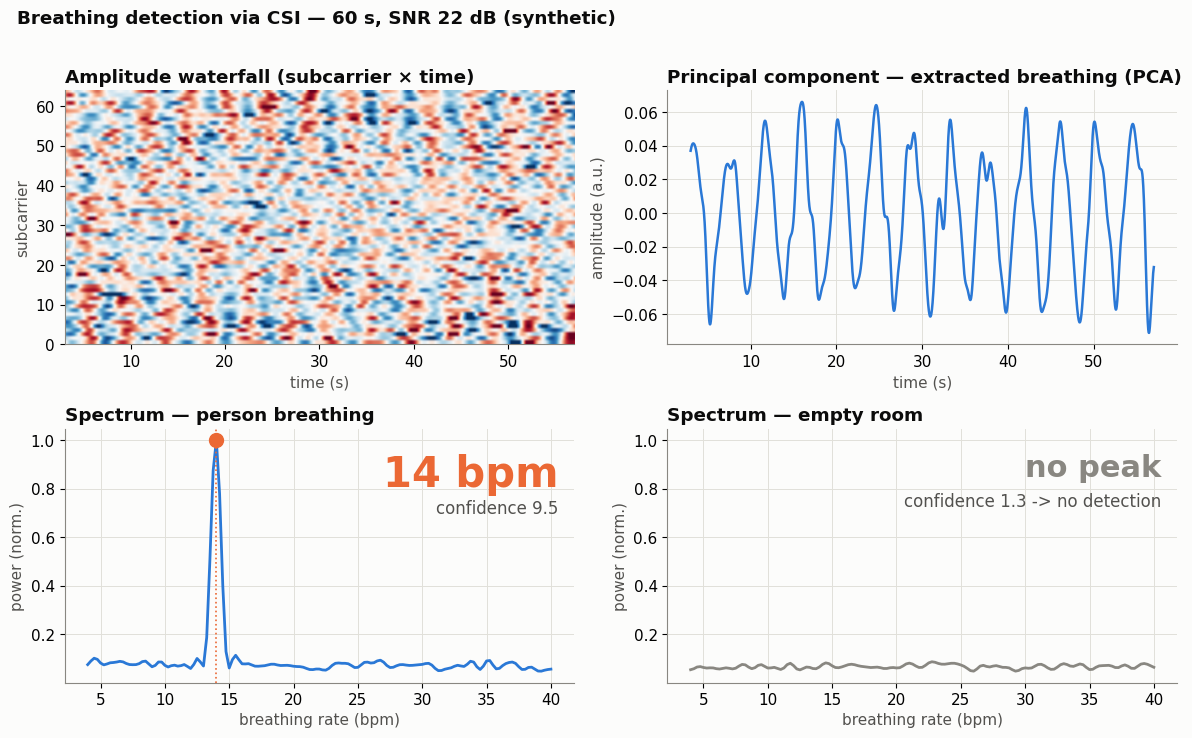

In [3]:
# --- palette ---
BLUE, ORANGE, MUT = "#2a78d6", "#eb6834", "#898781"
SURF, INK, INK2, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#e1e0d9"
plt.rcParams.update({"font.family": "sans-serif", "font.size": 11,
                     "axes.edgecolor": MUT, "axes.linewidth": 0.8})

t = np.arange(n) / fs
c0, c1 = int(3 * fs), int((DUR_S - 3) * fs)       # trim edge transients
amp_disp = lowpass(amp_resp, fs=fs, fc=0.5)       # more aggressive display filter

fr, P_resp = espectro(amp_resp)
_, P_vacio = espectro(amp_vacio)
esc = P_resp.max() + 1e-12                         # common scale to compare heights
bpm_axis = fr * 60.0
sel = (bpm_axis >= 4) & (bpm_axis <= 40)           # plotting range (bpm)

fig, ax = plt.subplots(2, 2, figsize=(12, 7.5), facecolor=SURF)
for a in ax.ravel():
    a.set_facecolor(SURF)
    for s in ("top", "right"):
        a.spines[s].set_visible(False)

# (a) waterfall: "raw" data (mean removed), robust global scale.
zc = (amp_disp - amp_disp.mean(0))[c0:c1]
vlim = np.percentile(np.abs(zc), 99) + 1e-12
ax[0, 0].imshow(zc.T, aspect="auto", origin="lower", cmap="RdBu_r",
                vmin=-vlim, vmax=vlim, extent=[c0 / fs, c1 / fs, 0, zc.shape[1]])
ax[0, 0].set_title("Amplitude waterfall (subcarrier × time)", color=INK,
                   fontweight="bold", loc="left")
ax[0, 0].set_xlabel("time (s)", color=INK2); ax[0, 0].set_ylabel("subcarrier", color=INK2)

# (b) principal component (SVD) = extracted breathing waveform.
# PCA over subcarriers finds the coherent temporal pattern (breathing) and
# rejects incoherent noise -> clean sinusoid.
Xc = amp_resp[c0:c1] - amp_resp[c0:c1].mean(0)
U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
pc1 = U[:, 0] * S[0]
ax[0, 1].plot(t[c0:c1], pc1, color=BLUE, linewidth=1.8)
ax[0, 1].set_title("Principal component — extracted breathing (PCA)", color=INK,
                   fontweight="bold", loc="left")
ax[0, 1].set_xlabel("time (s)", color=INK2); ax[0, 1].set_ylabel("amplitude (a.u.)", color=INK2)
ax[0, 1].grid(True, color=GRID, linewidth=0.7); ax[0, 1].set_axisbelow(True)

# (c) breathing spectrum: peak + rate in large type
ax[1, 0].plot(bpm_axis[sel], (P_resp / esc)[sel], color=BLUE, linewidth=2)
ip = int(np.argmax(P_resp[sel]))
bpm_pico = bpm_axis[sel][ip]
ax[1, 0].plot(bpm_pico, (P_resp / esc)[sel][ip], "o", color=ORANGE, markersize=10, zorder=5)
ax[1, 0].axvline(bpm_pico, color=ORANGE, linestyle=":", linewidth=1.2)
ax[1, 0].text(0.97, 0.9, f"{bpm_est:.0f} bpm", transform=ax[1, 0].transAxes,
              ha="right", va="top", fontsize=30, fontweight="bold", color=ORANGE)
ax[1, 0].text(0.97, 0.72, f"confidence {conf:.1f}", transform=ax[1, 0].transAxes,
              ha="right", va="top", fontsize=12, color=INK2)
ax[1, 0].set_title("Spectrum — person breathing", color=INK, fontweight="bold", loc="left")
ax[1, 0].set_xlabel("breathing rate (bpm)", color=INK2)
ax[1, 0].set_ylabel("power (norm.)", color=INK2)
ax[1, 0].grid(True, color=GRID, linewidth=0.7); ax[1, 0].set_axisbelow(True)

# (d) empty spectrum: same axis, flat
ax[1, 1].plot(bpm_axis[sel], (P_vacio / esc)[sel], color=MUT, linewidth=2)
ax[1, 1].text(0.97, 0.9, "no peak", transform=ax[1, 1].transAxes,
              ha="right", va="top", fontsize=22, fontweight="bold", color=MUT)
ax[1, 1].text(0.97, 0.75, f"confidence {conf_vac:.1f} -> no detection",
              transform=ax[1, 1].transAxes, ha="right", va="top", fontsize=12, color=INK2)
ax[1, 1].set_ylim(ax[1, 0].get_ylim())            # same scale as (c): honest comparison
ax[1, 1].set_title("Spectrum — empty room", color=INK, fontweight="bold", loc="left")
ax[1, 1].set_xlabel("breathing rate (bpm)", color=INK2)
ax[1, 1].set_ylabel("power (norm.)", color=INK2)
ax[1, 1].grid(True, color=GRID, linewidth=0.7); ax[1, 1].set_axisbelow(True)

fig.suptitle("Breathing detection via CSI — 60 s, SNR 22 dB (synthetic)",
             color=INK, fontweight="bold", x=0.02, ha="left")
fig.tight_layout(rect=[0, 0, 1, 0.97])
os.makedirs(os.path.join(ROOT, "figures"), exist_ok=True)
fig.savefig(os.path.join(ROOT, "figures", "demo_respiracion.png"), dpi=140,
            facecolor=SURF, bbox_inches="tight")
plt.show()

## What this shows

- The raw CSI **looks like noise** (waterfall), but breathing is inside it.
- **PCA** over subcarriers extracts the breathing waveform (rejects incoherent
  noise); the **FFT** with weighted subcarrier combining gives the frequency → **14 bpm**.
- The **confidence** (peak / band-mean) tells *breathing* (9.5) from *empty* (1.3):
  the system **refuses** when there is no signal, instead of inventing a number.

**Capture day:** replace `generate_breathing(...)` with `cargar_amplitudes("data/raw/…csv")`
from a real capture and re-run. Everything else stays the same.

> Honest limit: below ~15 dB SNR (likely through a wall) detection drops. That is
> where you measure the real SNR and decide between software (longer window) or a
> multi-antenna front-end.